### Graph V

In [51]:
from typing import TypedDict,List
from langgraph.graph import StateGraph, START, END

In [52]:
class AgentState(TypedDict):
   number1 : int
   operation: str
   number2: int
   output: int
    

In [53]:
def addition(state: AgentState) -> AgentState:
    """This function handles addition of different inputs"""
    
    state['output']= state['number1'] + state['number2']

    return state


def substraction(state: AgentState) -> AgentState:
    """This function handles substraction of different inputs"""
    
    state['output']= state['number1'] - state['number2']

    return state    


def decide_next_node(state: AgentState):
    if state['operation'] == '+':
        return 'addition_operation'      # ✅ return exact node name
    elif state['operation'] == '-':
        return 'substraction_operation'

In [54]:
# ✅ Always reinitialize first — prevents "already present" error on re-runs
graph = StateGraph(AgentState)

# Add nodes
graph.add_node('addition_operation', addition)
graph.add_node('substraction_operation', substraction)
graph.add_node('router', lambda state: state)

# Entry point
graph.add_edge(START, 'router')

# Conditional edges
graph.add_conditional_edges(
    'router',
    decide_next_node,
    {
        'addition_operation': 'addition_operation',
        'substraction_operation': 'substraction_operation'
    }
)

# Terminal edges
graph.add_edge('addition_operation', END)
graph.add_edge('substraction_operation', END)

app = graph.compile()


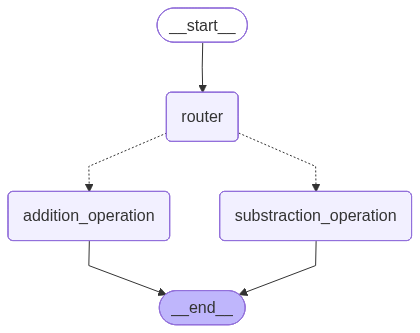

In [55]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [57]:
initial_state_1 = app.invoke({"number1":10, "operation":"+", "number2" : 5})

print(initial_state_1)

{'number1': 10, 'operation': '+', 'number2': 5, 'output': 15}
